# Real Estate Prices Dataset — Analysis

We will need to use two datasets for this analysis:

- `price-realestate.xlslx`, which maps the price of real estate according to the type of municipality
- `types-communes.csv`, which maps all swiss municipalities to a type (1 through 5)

The two datasets are not directly joinable via IDs, but they share a common conceptual classification:
- `price-realestate.xlslx` -> GemeindeTyp 1–5 (German categories)
- `types-communes.csv` -> Municipality categories

We will map them manually:
| GemeindeTyp | Category |
| ----------- | -------- |
| 1 | Urban municipality within a major metropolitan area |
| 2 | Urban municipality in a medium-sized metropolitan area |
| 3 | Urban municipality in a small town or outside an urban area |
| 4 | Intermediate municipality |
| 5 | Rural municipality |

In [ ]:
import pandas as pd

xls = pd.read_excel("../data/price-realestate.xlsx")
csv = pd.read_csv("../data/types-communes.csv")

df = xls.rename(columns={"Sprache / Langue / Lingua / Language": "type"})
df = df[df["type"].astype(str).str.contains("GemeindeTyp", na=False)]

df = df[["type", "Unnamed: 1"]].rename(columns={"Unnamed: 1": "value"})
df["type_id"] = df["type"].str.extract(r'(\d)').astype(int)

df = df.dropna(subset=["value"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")

agg = df.groupby("type_id")["value"].mean().reset_index()

mapping = {
    1: "Urban municipality within a major metropolitan area",
    2: "Urban municipality in a medium-sized metropolitan area",
    3: "Urban municipality in a small town or outside an urban area",
    4: "Intermediate municipality",
    5: "Rural municipality"
}

agg["category"] = agg["type_id"].map(mapping)

agg

,type_id,value,category
0,1,20.539333,Urban municipality within a major metropolitan...
1,2,12.999333,Urban municipality in a medium-sized metropoli...
2,3,6.984000,Urban municipality in a small town or outside ...
3,4,16.930667,Intermediate municipality
4,5,9.213333,Rural municipality


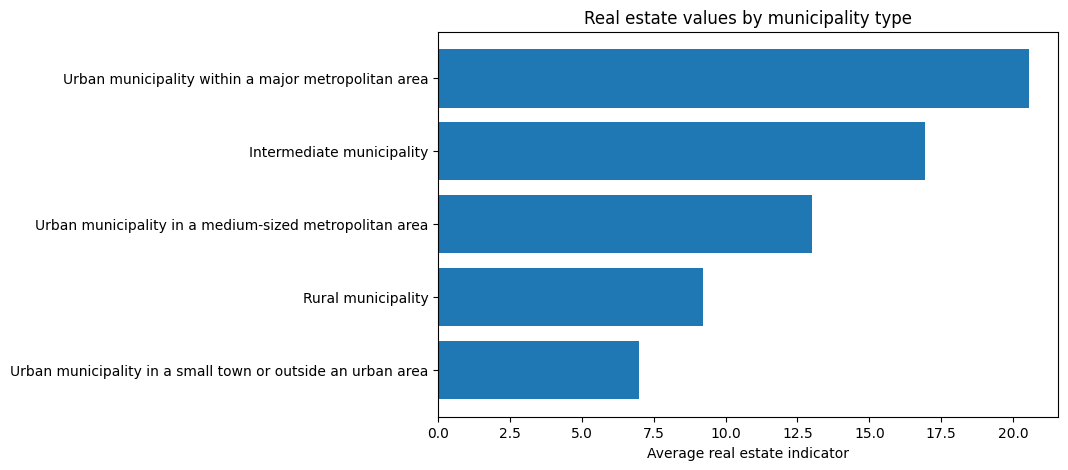

In [2]:
import matplotlib.pyplot as plt

agg_sorted = agg.sort_values("value", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(agg_sorted["category"], agg_sorted["value"])
plt.xlabel("Average real estate indicator")
plt.title("Real estate values by municipality type")
plt.gca().invert_yaxis()
plt.show()